### Step 1 — Mount Drive and define paths

In [1]:
# Step 1: Mount Google Drive and define paths

from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
OUT_DIR = BASE_DIR / "analysis" / "phase3_continuation"

OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_MANIFEST_PHASE3 = SPLIT_DIR / "train_pairs_3d_train_phase3_2000.json"
VAL_MANIFEST_PHASE3 = SPLIT_DIR / "train_pairs_3d_val_phase3_500.json"

LATEST_CKPT_PATH = CKPT_DIR / "conditional_unet3d_flow_phase3_train2000_val500_latest.pt"
BEST_CKPT_PATH = CKPT_DIR / "conditional_unet3d_flow_phase3_train2000_val500_best.pt"

CONT_LATEST_CKPT_PATH = CKPT_DIR / "conditional_unet3d_flow_phase3_train2000_val500_ep50_latest.pt"
CONT_BEST_CKPT_PATH = CKPT_DIR / "conditional_unet3d_flow_phase3_train2000_val500_ep50_best.pt"

print("Train manifest exists:", TRAIN_MANIFEST_PHASE3.exists())
print("Val manifest exists:", VAL_MANIFEST_PHASE3.exists())
print("Latest checkpoint exists:", LATEST_CKPT_PATH.exists())
print("Best checkpoint exists:", BEST_CKPT_PATH.exists())
print("OUT_DIR exists:", OUT_DIR.exists())

Mounted at /content/drive
Train manifest exists: True
Val manifest exists: True
Latest checkpoint exists: True
Best checkpoint exists: True
OUT_DIR exists: True


### Step 2 — Imports and speed settings

In [2]:
# Step 2: Imports and speed settings

import json
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

torch.backends.cudnn.benchmark = True

### Step 3 — Reuse dataset and model definitions

In [3]:
# Step 3: Reuse existing definitions
# Required before continuing:
# - CubePair3DDataset
# - ConditionalUNetFlow3D
# - euler_sample_flow_3d
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1,D,H,W)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1,D,H,W)

        return x0, x1


class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)



class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        # xt, x0: (B,1,D,H,W)
        # t:      (B,1,1,1,1)
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])  # (B,1,D,H,W)
        inp = torch.cat([xt, x0, t_map], dim=1)  # (B,3,D,H,W)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b  = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)  # predicted velocity


@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    """
    x0: (B,1,D,H,W)
    """
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### Step 4 — Set seeds and device

In [4]:
# Step 4: Set seeds and device

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA H100 80GB HBM3


### Step 5 — Build datasets and loaders

In [5]:
# Step 5: Build datasets and loaders

DOSE_SCALE = 1000.0
BATCH_SIZE = 2
NUM_WORKERS = 2

train_dataset_3d = CubePair3DDataset(TRAIN_MANIFEST_PHASE3, dose_scale=DOSE_SCALE)
val_dataset_3d = CubePair3DDataset(VAL_MANIFEST_PHASE3, dose_scale=DOSE_SCALE)

train_loader_3d = DataLoader(
    train_dataset_3d,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

val_loader_3d = DataLoader(
    val_dataset_3d,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

print("Train dataset length:", len(train_dataset_3d))
print("Val dataset length:", len(val_dataset_3d))
print("Train batches:", len(train_loader_3d))
print("Val batches:", len(val_loader_3d))

Train dataset length: 2000
Val dataset length: 500
Train batches: 1000
Val batches: 250


### Step 6 — Build model and load latest checkpoint

In [6]:
# Step 6: Build model and load the latest checkpoint

BASE_CH = 24

flow_model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=BASE_CH).to(device)

latest_ckpt = torch.load(LATEST_CKPT_PATH, map_location="cpu")
flow_model.load_state_dict(latest_ckpt["model_state_dict"])

print("Loaded latest checkpoint successfully.")
print("Checkpoint epoch:", latest_ckpt["epoch"])

Loaded latest checkpoint successfully.
Checkpoint epoch: 30


### Step 7 — Restore optimizer and set continuation schedule

In [7]:
# Step 7A: Restore optimizer and keep the same learning rate

LR_CONT = 3e-4
START_EPOCH = latest_ckpt["epoch"]          # should be 30
TARGET_EPOCH = 50
N_CONT_EPOCHS = TARGET_EPOCH - START_EPOCH  # should be 20

optimizer = torch.optim.Adam(flow_model.parameters(), lr=LR_CONT)

# Restore optimizer state from the latest checkpoint
optimizer.load_state_dict(latest_ckpt["optimizer_state_dict"])

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print("Start epoch:", START_EPOCH)
print("Target epoch:", TARGET_EPOCH)
print("Continuation epochs:", N_CONT_EPOCHS)
print("Continuation learning rate:", optimizer.param_groups[0]["lr"])

Start epoch: 30
Target epoch: 50
Continuation epochs: 20
Continuation learning rate: 0.0003


/tmp/ipykernel_735/1399666371.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


### Step 8 — Reuse previous losses

In [8]:
# Step 8: Reuse previous loss history

train_losses = latest_ckpt.get("train_losses", []).copy()
val_losses = latest_ckpt.get("val_losses", []).copy()

best_val_loss = min(val_losses) if len(val_losses) > 0 else float("inf")
best_epoch = int(np.argmin(val_losses)) + 1 if len(val_losses) > 0 else -1

print("Loaded previous train loss length:", len(train_losses))
print("Loaded previous val loss length:", len(val_losses))
print("Previous best val loss:", best_val_loss)
print("Previous best epoch:", best_epoch)

Loaded previous train loss length: 30
Loaded previous val loss length: 30
Previous best val loss: 2.3445045058906544e-05
Previous best epoch: 26


### Step 9 — Loss functions and lightweight train/eval functions

In [9]:
# Step 9: Loss functions and lightweight train/eval functions

def sample_t_like(x):
    return torch.rand((x.shape[0], 1, 1, 1, 1), device=x.device)


def compute_flow_matching_loss(model, x0, x1):
    t = sample_t_like(x0)
    z_t = (1.0 - t) * x0 + t * x1
    v_target = x1 - x0
    v_pred = model(z_t, x0, t)
    return F.mse_loss(v_pred, v_target)


def train_one_epoch_flow(model, loader, optimizer, device, scaler):
    model.train()

    total_loss = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device, non_blocking=True)
        x1 = x1.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            loss = compute_flow_matching_loss(model, x0, x1)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate_flow_matching_loss(model, loader, device):
    model.eval()

    total_loss = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device, non_blocking=True)
        x1 = x1.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            loss = compute_flow_matching_loss(model, x0, x1)

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)

### Step 10 — Checkpoint saving

In [10]:
# Step 10: Save continuation checkpoint

def save_checkpoint(path, model, optimizer, epoch, train_losses, val_losses, best_val_loss):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss,
        "config": {
            "base_ch": BASE_CH,
            "batch_size": BATCH_SIZE,
            "dose_scale": DOSE_SCALE,
            "train_manifest": str(TRAIN_MANIFEST_PHASE3),
            "val_manifest": str(VAL_MANIFEST_PHASE3),
        }
    }, path)

    print("Saved checkpoint:", path)

### Step 11 — Lightweight continuation training loop

In [11]:
# Step 11: Lightweight continuation training loop

for epoch in range(START_EPOCH + 1, TARGET_EPOCH + 1):
    train_loss = train_one_epoch_flow(flow_model, train_loader_3d, optimizer, device, scaler)
    val_loss = evaluate_flow_matching_loss(flow_model, val_loader_3d, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch}/{TARGET_EPOCH} | "
        f"train loss = {train_loss:.6f} | "
        f"val loss = {val_loss:.6f}"
    )

    save_checkpoint(
        CONT_LATEST_CKPT_PATH,
        flow_model,
        optimizer,
        epoch,
        train_losses,
        val_losses,
        best_val_loss
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch

        save_checkpoint(
            CONT_BEST_CKPT_PATH,
            flow_model,
            optimizer,
            epoch,
            train_losses,
            val_losses,
            best_val_loss
        )

        print(f"New continuation best validation loss at epoch {epoch}: {best_val_loss:.6f}")

/tmp/ipykernel_735/3485369477.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_735/3485369477.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch 31/50 | train loss = 0.000040 | val loss = 0.000033
Saved checkpoint: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_unet3d_flow_phase3_train2000_val500_ep50_latest.pt
Epoch 32/50 | train loss = 0.000034 | val loss = 0.000064
Saved checkpoint: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_unet3d_flow_phase3_train2000_val500_ep50_latest.pt
Epoch 33/50 | train loss = 0.000046 | val loss = 0.000058
Saved checkpoint: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_unet3d_flow_phase3_train2000_val500_ep50_latest.pt
Epoch 34/50 | train loss = 0.000049 | val loss = 0.000026
Saved checkpoint: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_unet3d_flow_phase3_train2000_val500_ep50_latest.pt
Epoch 35/50 | train loss = 0.000030 | val loss = 0.000038
Saved checkpoint: /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_unet3d_flow_phase3_train20

### Step 12 — Plot the full 1–50 loss curve

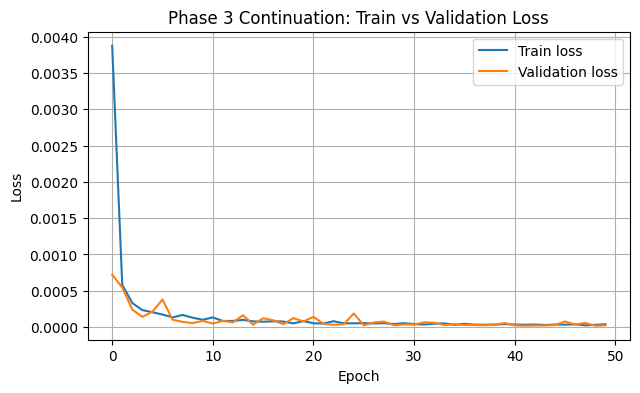

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_continuation/phase3_continuation_loss_full.png


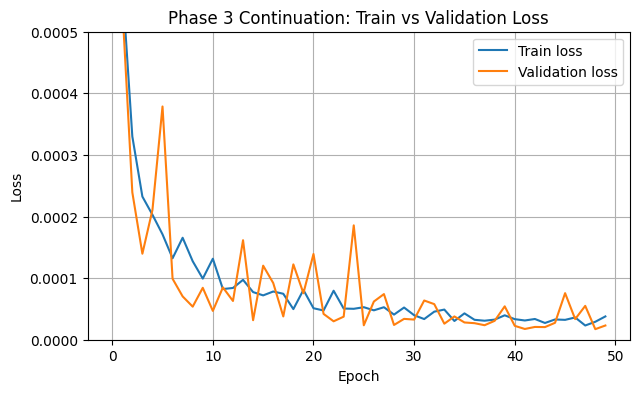

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_continuation/phase3_continuation_loss_scaled_0_to_5e-4.png


In [12]:
# Step 12: Plot the full 1...50 loss curve

def plot_loss_curve(train_losses, val_losses, save_path, scaled=False):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(train_losses, label="Train loss")
    ax.plot(val_losses, label="Validation loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Phase 3 Continuation: Train vs Validation Loss")
    if scaled:
        ax.set_ylim(0.0, 5e-4)
    ax.grid(True)
    ax.legend()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

plot_loss_curve(
    train_losses,
    val_losses,
    OUT_DIR / "phase3_continuation_loss_full.png",
    scaled=False
)

plot_loss_curve(
    train_losses,
    val_losses,
    OUT_DIR / "phase3_continuation_loss_scaled_0_to_5e-4.png",
    scaled=True
)

### Step 13 — Post-training full validation metrics

In [13]:
# Step 13: Full validation metrics after continuation

@torch.no_grad()
def evaluate_flow_prediction_metrics(model, loader, device, n_steps=30):
    model.eval()

    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device, non_blocking=True)
        x1 = x1.to(device, non_blocking=True)

        pred = euler_sample_flow_3d(model, x0, n_steps=n_steps)

        total_mse += F.mse_loss(pred, x1).item()
        total_mae += F.l1_loss(pred, x1).item()
        n_batches += 1

    return {
        "mse": total_mse / max(n_batches, 1),
        "mae": total_mae / max(n_batches, 1)
    }

best_ckpt_cont = torch.load(CONT_BEST_CKPT_PATH, map_location="cpu")
flow_model.load_state_dict(best_ckpt_cont["model_state_dict"])
flow_model.eval()

val_metrics_cont = evaluate_flow_prediction_metrics(flow_model, val_loader_3d, device, n_steps=30)

print("Continuation best checkpoint validation metrics:")
print(val_metrics_cont)
print("Continuation best epoch:", best_epoch)
print("Continuation best val loss:", best_val_loss)

Continuation best checkpoint validation metrics:
{'mse': 1.959155906297383e-05, 'mae': 0.0029125171219930054}
Continuation best epoch: 49
Continuation best val loss: 1.7157049018351246e-05


### Step 14 — Save a concise continuation summary

In [14]:
# Step 14: Save continuation summary

continuation_summary = {
    "start_epoch": START_EPOCH,
    "target_epoch": TARGET_EPOCH,
    "continuation_lr": optimizer.param_groups[0]["lr"],
    "best_epoch_after_continuation": best_epoch,
    "best_val_loss_after_continuation": best_val_loss,
    "final_train_loss_after_continuation": train_losses[-1],
    "final_val_loss_after_continuation": val_losses[-1],
    "final_val_mse_after_continuation": val_metrics_cont["mse"],
    "final_val_mae_after_continuation": val_metrics_cont["mae"],
    "continuation_best_checkpoint": str(CONT_BEST_CKPT_PATH),
    "continuation_latest_checkpoint": str(CONT_LATEST_CKPT_PATH),
}

summary_path = OUT_DIR / "phase3_continuation_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(continuation_summary, f, indent=2)

print("Saved:", summary_path)
print(json.dumps(continuation_summary, indent=2))

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_continuation/phase3_continuation_summary.json
{
  "start_epoch": 30,
  "target_epoch": 50,
  "continuation_lr": 0.0003,
  "best_epoch_after_continuation": 49,
  "best_val_loss_after_continuation": 1.7157049018351246e-05,
  "final_train_loss_after_continuation": 3.781664631924286e-05,
  "final_val_loss_after_continuation": 2.3082465453626356e-05,
  "final_val_mse_after_continuation": 1.959155906297383e-05,
  "final_val_mae_after_continuation": 0.0029125171219930054,
  "continuation_best_checkpoint": "/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_unet3d_flow_phase3_train2000_val500_ep50_best.pt",
  "continuation_latest_checkpoint": "/content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/conditional_unet3d_flow_phase3_train2000_val500_ep50_latest.pt"
}
